In [112]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt

In [159]:
dat = pd.read_csv('/content/f1 dataset.csv')
dat

,Driver,Nationality,Seasons,Championships,Race_Entries,Race_Starts,Pole_Positions,Race_Wins,Podiums,Fastest_Laps,...,Championship Years,Decade,Pole_Rate,Start_Rate,Win_Rate,Podium_Rate,FastLap_Rate,Points_Per_Entry,Years_Active,Champion
0,Jack Aitken,United Kingdom,[2020],0,1,1,0,0,0,0,...,NaN,2020,0.00000,1.000000,0.000000,0.000000,0.000000,0.000000,1,False
1,Alexander Albon,Thailand,"[2019, 2020, 2022]",0,61,60,0,0,2,0,...,NaN,2020,0.00000,0.983607,0.000000,0.032787,0.000000,3.311475,3,False
2,Valtteri Bottas,Finland,"[2013, 2014, 2015, 2016, 2017, 2018, 2019, 202...",0,202,201,20,10,67,19,...,NaN,2020,0.09901,0.995050,0.049505,0.331683,0.094059,8.866337,10,False
3,Marcus Ericsson,Sweden,"[2014, 2015, 2016, 2017, 2018]",0,97,97,0,0,0,0,...,NaN,2020,0.00000,1.000000,0.000000,0.000000,0.000000,0.185567,5,False
4,Pietro Fittipaldi,Brazil,[2020],0,2,2,0,0,0,0,...,NaN,2020,0.00000,1.000000,0.000000,0.000000,0.000000,0.000000,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
863,Spider Webb,United States,"[1950, 1952, 1953, 1954]",0,5,4,0,0,0,0,...,NaN,1950,0.00000,0.800000,0.000000,0.000000,0.000000,0.000000,4,False
864,Ken Wharton,United Kingdom,"[1952, 1953, 1954, 1955]",0,16,15,0,0,0,0,...,NaN,1950,0.00000,0.937500,0.000000,0.000000,0.000000,0.187500,4,False
865,Graham Whitehead,United Kingdom,[1952],0,1,1,0,0,0,0,...,NaN,1950,0.00000,1.000000,0.000000,0.000000,0.000000,0.000000,1,False
866,Peter Whitehead,United Kingdom,"[1950, 1951, 1952, 1953, 1954]",0,12,10,0,0,1,0,...,NaN,1950,0.00000,0.833333,0.000000,0.083333,0.000000,0.333333,5,False


In [5]:
dat.describe()

,Championships,Race_Entries,Race_Starts,Pole_Positions,Race_Wins,Podiums,Fastest_Laps,Points,Decade,Pole_Rate,Start_Rate,Win_Rate,Podium_Rate,FastLap_Rate,Points_Per_Entry,Years_Active
count,868.000000,868.000000,868.000000,868.000000,868.000000,868.000000,868.000000,868.000000,868.000000,868.000000,868.000000,868.000000,868.000000,868.000000,868.000000,868.000000
mean,0.084101,29.917051,27.694700,1.244240,1.247696,3.756912,1.261521,55.849459,1972.223502,0.011471,0.779824,0.011050,0.041389,0.011894,0.479158,3.664747
std,0.524883,53.780150,52.876476,6.347512,6.491921,14.432826,5.413644,265.968614,20.201084,0.046544,0.324303,0.043579,0.106457,0.043514,1.213826,3.501761
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1960.000000,0.000000,0.666667,0.000000,0.000000,0.000000,0.000000,1.000000
50%,0.000000,7.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1970.000000,0.000000,0.962251,0.000000,0.000000,0.000000,0.000000,2.000000
75%,0.000000,29.250000,26.000000,0.000000,0.000000,0.000000,0.000000,8.000000,1982.500000,0.000000,1.000000,0.000000,0.000000,0.000000,0.382517,5.000000
max,7.000000,359.000000,356.000000,103.000000,103.000000,191.000000,77.000000,4415.500000,2020.000000,0.557692,1.000000,0.461538,1.000000,0.500000,14.197749,19.000000


In [7]:
dat.corr(numeric_only=True)

,Championships,Race_Entries,Race_Starts,Pole_Positions,Race_Wins,Podiums,Fastest_Laps,Points,Active,Decade,Pole_Rate,Start_Rate,Win_Rate,Podium_Rate,FastLap_Rate,Points_Per_Entry,Years_Active,Champion
Championships,1.000000,0.462985,0.471073,0.869342,0.915247,0.808274,0.829641,0.655567,0.136394,0.105263,0.675121,0.101046,0.730320,0.549377,0.583335,0.596426,0.419484,0.794025
Race_Entries,0.462985,1.000000,0.996701,0.582264,0.590658,0.757007,0.681107,0.689361,0.273960,0.498214,0.360392,0.250540,0.391760,0.440430,0.387468,0.636681,0.849973,0.486117
Race_Starts,0.471073,0.996701,1.000000,0.591793,0.600889,0.768449,0.691432,0.701817,0.282485,0.489603,0.367880,0.275386,0.400482,0.451132,0.395277,0.651703,0.844593,0.493139
Pole_Positions,0.869342,0.582264,0.591793,1.000000,0.954951,0.901514,0.899697,0.799746,0.203489,0.181147,0.724572,0.122427,0.702441,0.566939,0.583367,0.713732,0.495873,0.680263
Race_Wins,0.915247,0.590658,0.600889,0.954951,1.000000,0.934082,0.931840,0.811054,0.200064,0.177587,0.641202,0.121174,0.715301,0.574145,0.574646,0.709542,0.503717,0.701635
Podiums,0.808274,0.757007,0.768449,0.901514,0.934082,1.000000,0.944862,0.879007,0.240542,0.242973,0.582819,0.161073,0.646987,0.626834,0.561148,0.784089,0.643342,0.688053
Fastest_Laps,0.829641,0.681107,0.691432,0.899697,0.931840,0.944862,1.000000,0.794033,0.194105,0.213626,0.640768,0.144872,0.691881,0.598409,0.657703,0.718784,0.586038,0.686109
Points,0.655567,0.689361,0.701817,0.799746,0.811054,0.879007,0.794033,1.000000,0.423763,0.305172,0.440628,0.133449,0.480722,0.467058,0.402949,0.857405,0.516597,0.521929
Active,0.136394,0.273960,0.282485,0.203489,0.200064,0.240542,0.194105,0.423763,1.000000,0.355812,0.104031,0.101060,0.100375,0.115058,0.110761,0.483027,0.128803,0.087734
Decade,0.105263,0.498214,0.489603,0.181147,0.177587,0.242973,0.213626,0.305172,0.355812,1.000000,0.033489,0.105855,0.032219,0.007738,0.044675,0.260378,0.230504,0.110126


,Driver,Nationality,Seasons,Championships,Race_Entries,Race_Starts,Pole_Positions,Race_Wins,Podiums,Fastest_Laps,...,Championship Years,Decade,Pole_Rate,Start_Rate,Win_Rate,Podium_Rate,FastLap_Rate,Points_Per_Entry,Years_Active,Champion
308,Keke Rosberg,Finland,"[1978, 1979, 1980, 1981, 1982, 1983, 1984, 198...",1,128,114,5,5,17,3,...,[1982],1980,0.039062,0.890625,0.039062,0.132812,0.023438,1.246094,9,1
542,Mike Hawthorn,United Kingdom,"[1952, 1953, 1954, 1955, 1956, 1957, 1958]",1,47,45,4,3,18,6,...,[1958],1960,0.085106,0.957447,0.063830,0.382979,0.127660,2.396596,7,1
545,Phil Hill,United States,"[1958, 1959, 1960, 1961, 1962, 1963, 1964, 1966]",1,52,49,6,3,16,6,...,[1961],1960,0.115385,0.942308,0.057692,0.307692,0.115385,1.807692,8,1
730,Nino Farina,Italy,"[1950, 1951, 1952, 1953, 1954, 1955]",1,34,33,5,5,20,5,...,[1950],1950,0.147059,0.970588,0.147059,0.588235,0.147059,3.392059,6,1


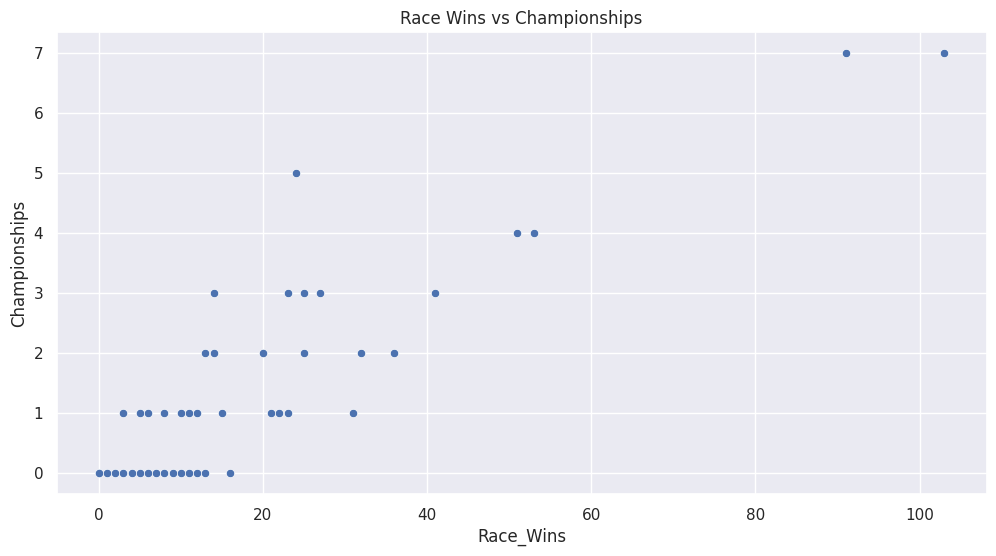

In [131]:
#Race Wins vs Championships Scatterplot

ax = sns.scatterplot(data=dat, x='Race_Wins', y='Championships')
ax.set_title("Race Wins vs Championships")
#sns.boxplot(data=dat, x='Race_Wins', y='Championships')
dat[(dat['Championships'] == 1) & (dat['Race_Wins'] <= 5)]#[['Driver', 'Nationality', 'Race_Wins', 'Championship Years']]


In [161]:
#Comparing Averages of Outliers

few_wins_champs = dat[(dat['Championships'] >= 1) & (dat['Race_Wins'] <= 5)]
allchamps = dat[dat['Championships'] >= 1]

avg_few_wins_champs = few_wins_champs['Podium_Rate'].mean()
avg_allchamps = allchamps['Podium_Rate'].mean()

print("Average of <=5 Win Champions, Average of all champions")
print(avg_few_wins_champs, avg_allchamps)
stats.ttest_ind(few_wins_champs['Podium_Rate'], allchamps['Podium_Rate'])

print(few_wins_champs['Pole_Rate'].mean())
print(allchamps['Pole_Rate'].mean())



Average of <=5 Win Champions, Average of all champions
0.3529297063035525 0.3374597377823853
0.09665308047850674
0.15734211364835554


Text(0.5, 0, 'Podium Rate')

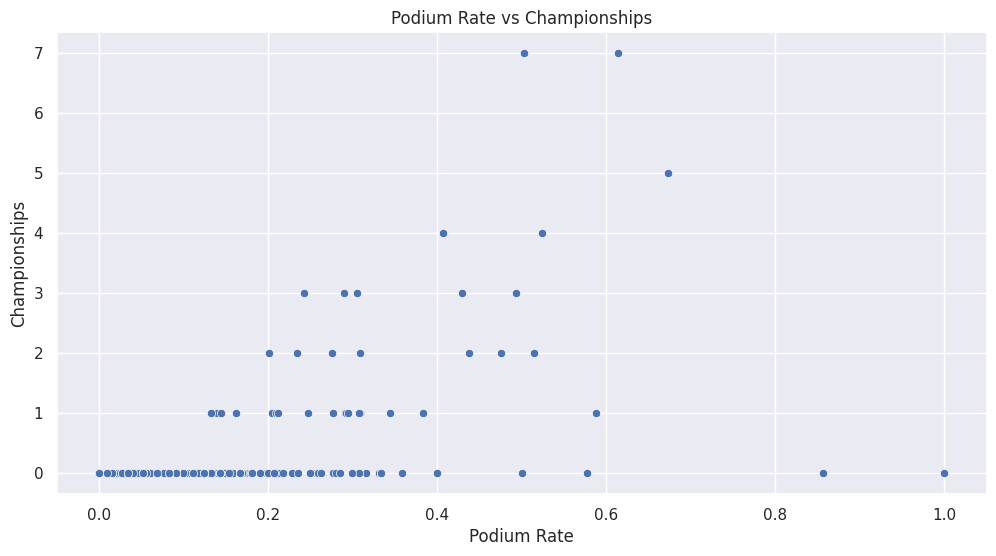

In [163]:
#Podium Rate vs Championships Scatterplot


ax2 = sns.scatterplot(data=dat, x='Podium_Rate', y='Championships')
ax2.set_title("Podium Rate vs Championships")
ax2.set_xlabel("Podium Rate")

TtestResult(statistic=15.482605837892136, pvalue=6.481126898145253e-48, df=866.0)

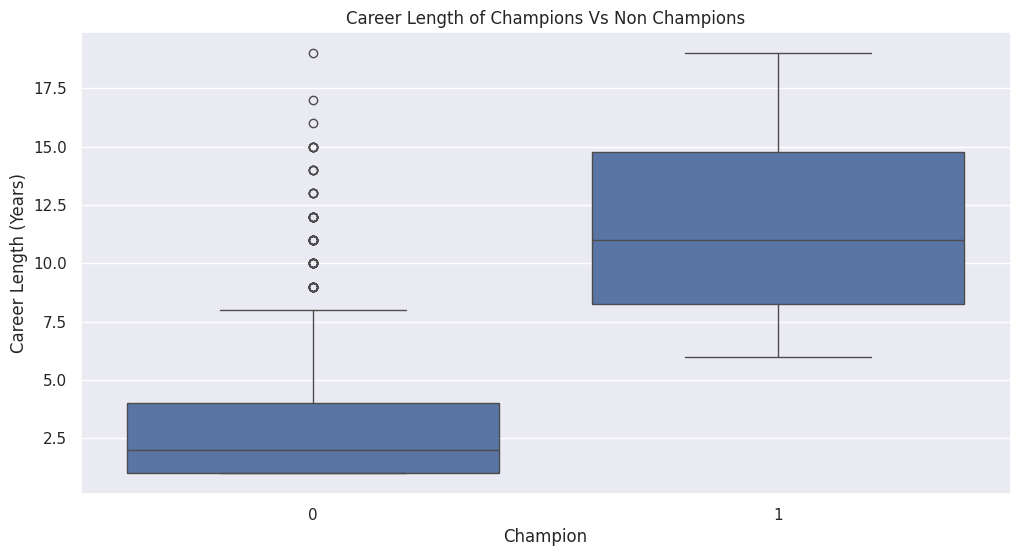

In [164]:
#Champion vs NonChampion Boxplot

dat['Champion'] = dat['Champion'].astype(int)
ax1 = sns.boxplot(data=dat, x='Champion', y='Years_Active')
ax1.set_ylabel("Career Length (Years)")
ax1.set_title("Career Length of Champions Vs Non Champions")

champions = dat[dat['Champion'] == 1]['Years_Active']
nonchampions = dat[dat['Champion'] == 0]['Years_Active']
stats.ttest_ind(champions, nonchampions)

<Axes: xlabel='Career Length', ylabel='Championships'>

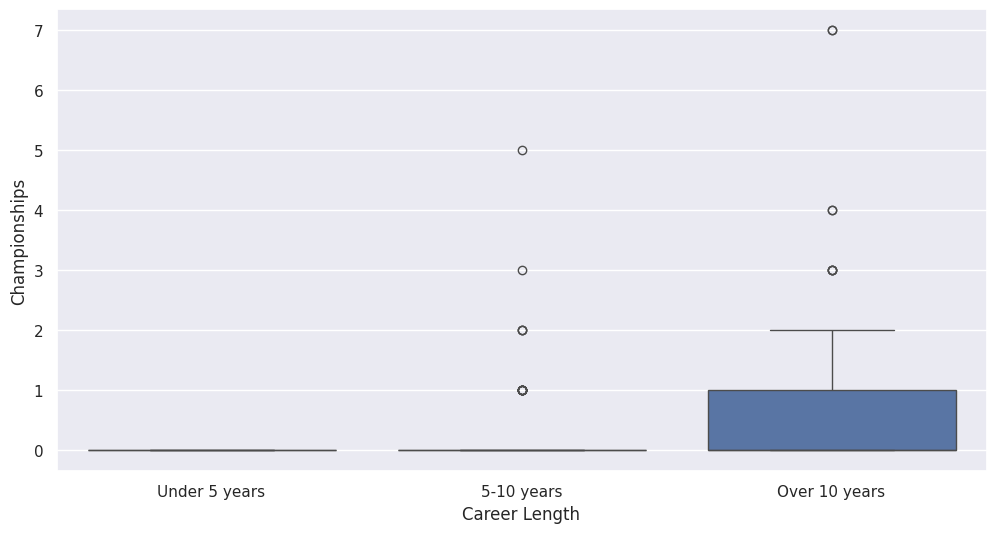

In [158]:
#Creating a new categorical variable

career5 = dat[dat['Years_Active'] < 5].copy()
career5to10 = dat[(dat['Years_Active'] >= 5) & (dat['Years_Active'] <= 10)].copy()
career10 = dat[dat['Years_Active'] > 10].copy()

career5['Career Length'] = 'Under 5 years'
career5to10['Career Length'] = '5-10 years'
career10['Career Length'] = 'Over 10 years'

newdat = pd.concat([career5, career5to10, career10])
newdat


#Career Length vs Championships Boxplot
sns.boxplot(data=newdat, x='Career Length', y='Championships')

Text(0.5, 0, 'Pole Rate')

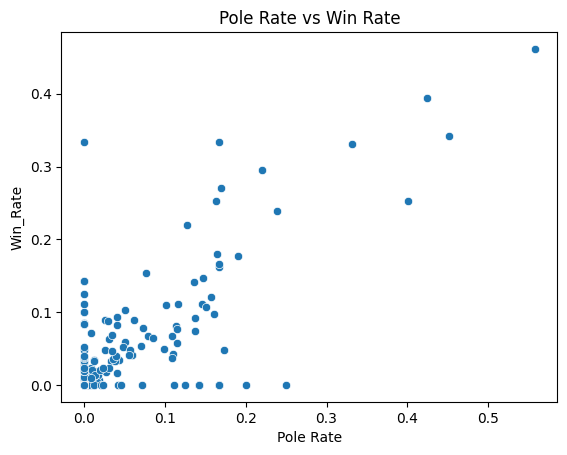

In [96]:
#Pole Rate vs Win Rate Scatterplot

ax2 = sns.scatterplot(x='Pole_Rate', y='Win_Rate', data=dat)
ax2.set_title("Pole Rate vs Win Rate")
ax2.set_xlabel("Pole Rate")

       Nationality  Championships
0        Argentina       0.200000
1        Australia       0.222222
2          Austria       0.250000
5           Brazil       0.250000
6           Canada       0.066667
14         Finland       0.444444
15          France       0.055556
16         Germany       0.857143
21           Italy       0.030303
29     Netherlands       0.125000
30     New Zealand       0.111111
37    South Africa       0.043478
38           Spain       0.133333
42  United Kingdom       0.121951
43   United States       0.012500


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14],
 [Text(0, 0, 'Argentina'),
  Text(1, 0, 'Australia'),
  Text(2, 0, 'Austria'),
  Text(3, 0, 'Brazil'),
  Text(4, 0, 'Canada'),
  Text(5, 0, 'Finland'),
  Text(6, 0, 'France'),
  Text(7, 0, 'Germany'),
  Text(8, 0, 'Italy'),
  Text(9, 0, 'Netherlands'),
  Text(10, 0, 'New Zealand'),
  Text(11, 0, 'South Africa'),
  Text(12, 0, 'Spain'),
  Text(13, 0, 'United Kingdom'),
  Text(14, 0, 'United States')])

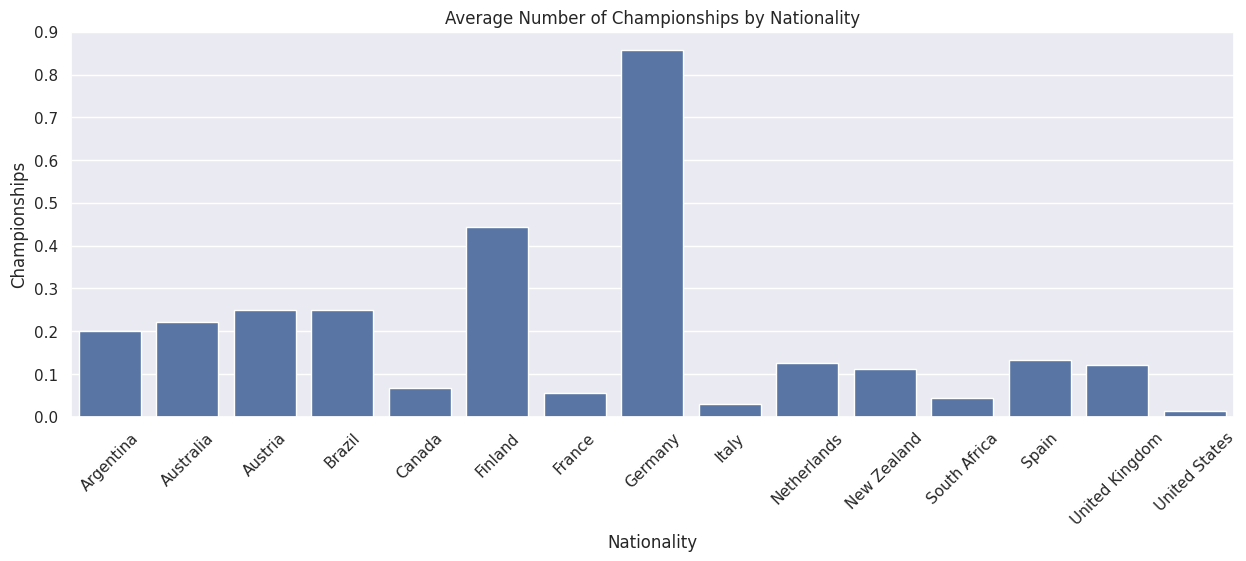

In [166]:
#Grouping Data By Nationality

avg_champ_dat = dat.groupby('Nationality')['Championships'].mean().reset_index()
avg_champ_dat = avg_champ_dat[avg_champ_dat['Championships'] > 0]
print(avg_champ_dat)


#Avg Championships by Nationality Bar Plot
plt.figure(figsize=(15, 5))
axnat = sns.barplot(data=avg_champ_dat, x='Nationality', y='Championships')
axnat.set_title("Average Number of Championships by Nationality")
plt.xticks(rotation=45)


In [160]:
dat[dat['Nationality'] == "Germany"] #14 drivers 12 championships
dat[dat['Nationality'] == "West Germany"] #39 drivers 0 championships
dat[dat['Nationality'] == "East Germany"] #3 drivers 0 championships

,Driver,Nationality,Seasons,Championships,Race_Entries,Race_Starts,Pole_Positions,Race_Wins,Podiums,Fastest_Laps,...,Championship Years,Decade,Pole_Rate,Start_Rate,Win_Rate,Podium_Rate,FastLap_Rate,Points_Per_Entry,Years_Active,Champion
735,Theo Fitzau,East Germany,[1953],0,1,1,0,0,0,0,...,NaN,1950,0.0,1.0,0.0,0.0,0.0,0.0,1,False
776,Ernst Klodwig,East Germany,"[1952, 1953]",0,2,2,0,0,0,0,...,NaN,1950,0.0,1.0,0.0,0.0,0.0,0.0,2,False
778,Rudolf Krause,East Germany,"[1952, 1953]",0,2,2,0,0,0,0,...,NaN,1950,0.0,1.0,0.0,0.0,0.0,0.0,2,False


Text(0, 0.5, 'Career Length (In Years)')

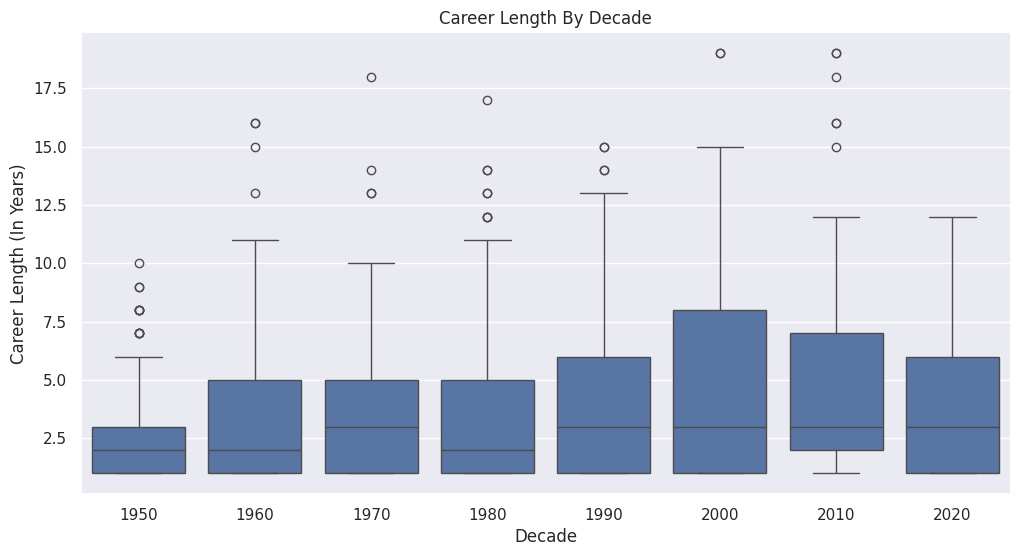

In [134]:
#Career Length by Decade Boxplot

axdec = sns.boxplot(data=dat, x='Decade', y='Years_Active')
axdec.set_title("Career Length By Decade")
axdec.set_ylabel("Career Length (In Years)")